Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/nudratabbas/multi-location-healthcare-clinic-revenue-dataset
License(s): CC0-1.0
multi-location-healthcare-clinic-revenue-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
['clinics.csv', 'appointments.csv', 'patients.csv']
   appointment_id  patient_id  clinic_id  doctor_id         specialty  \
0               1        4572          5         27       Dermatology   
1               2         126          2          8               ENT   
2               3        2314          4         28        Pediatrics   
3               4        3318          5         28               ENT   
4               5        2569          6          5  General Medicine   

  appointment_date  booking_lead_time_days appointment_time_slot  \
0       2024-07-04                       8               Evening   
1       2024-04-09                      12             Afternoon   
2       2

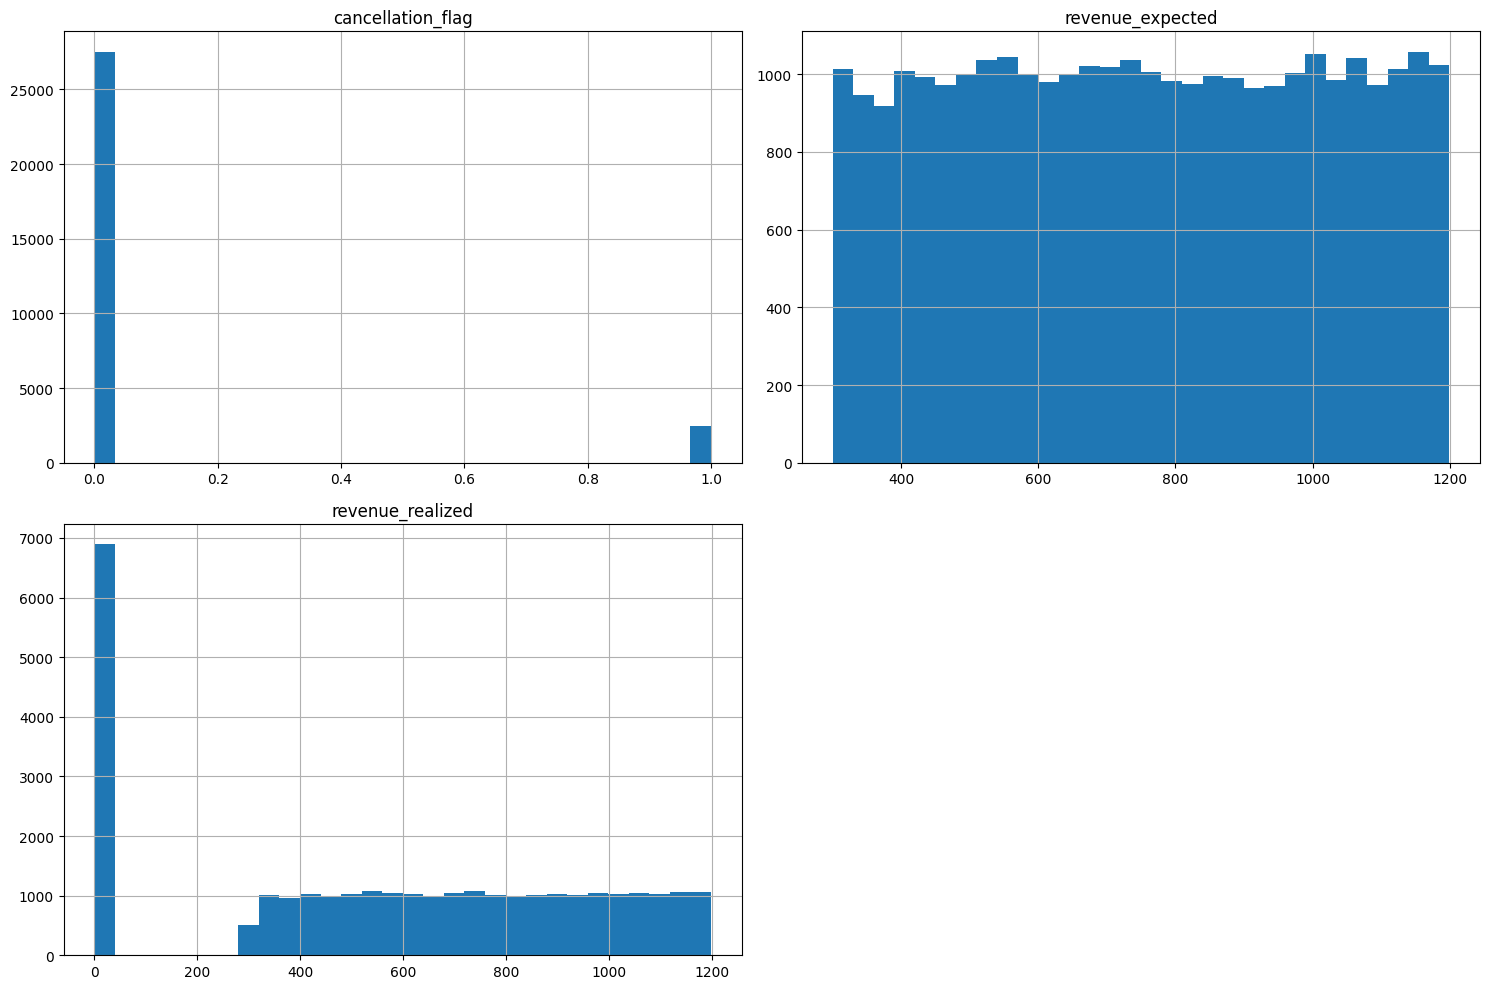

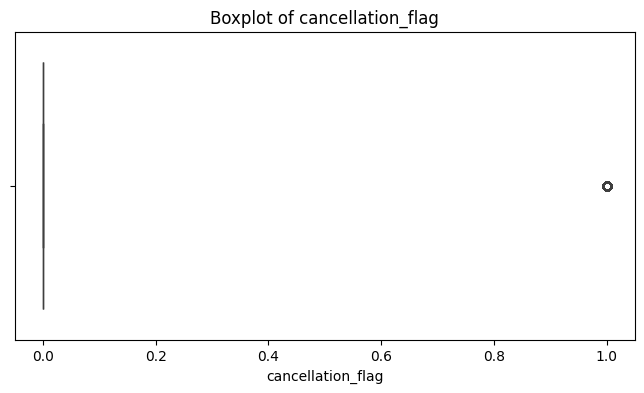

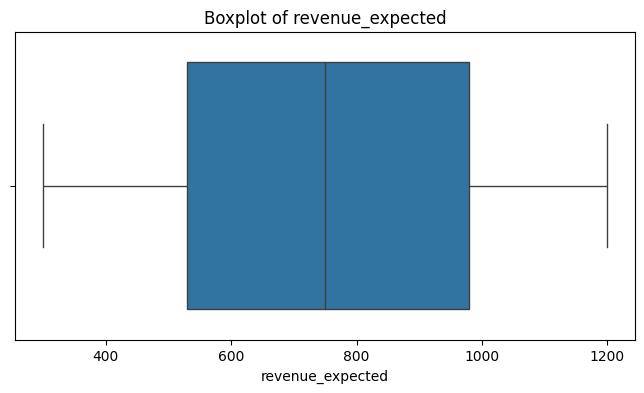

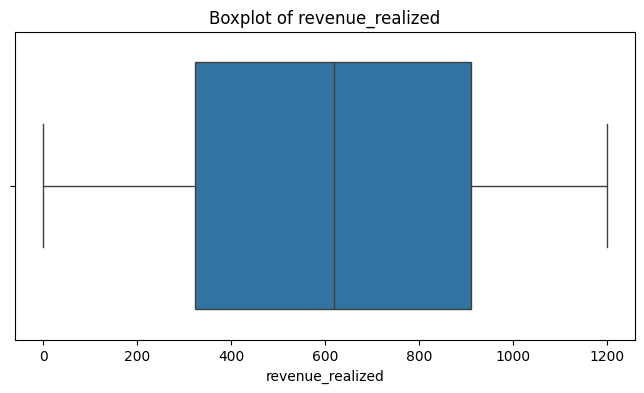

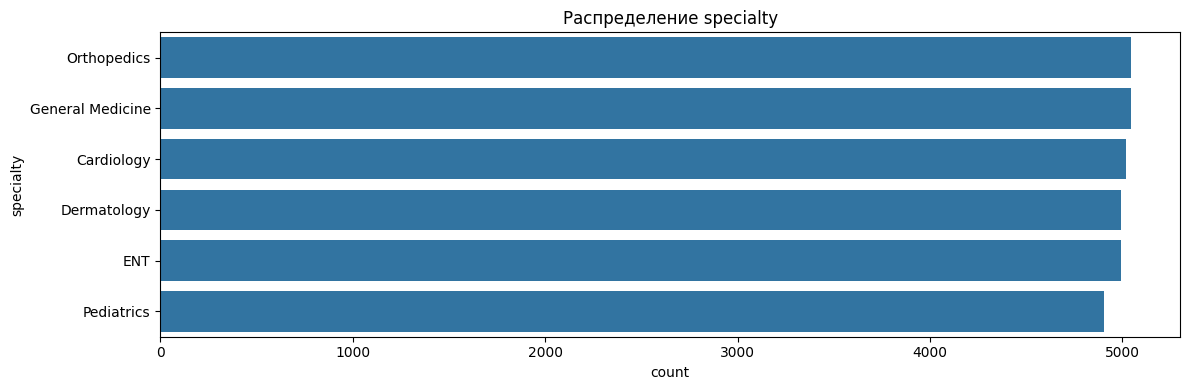

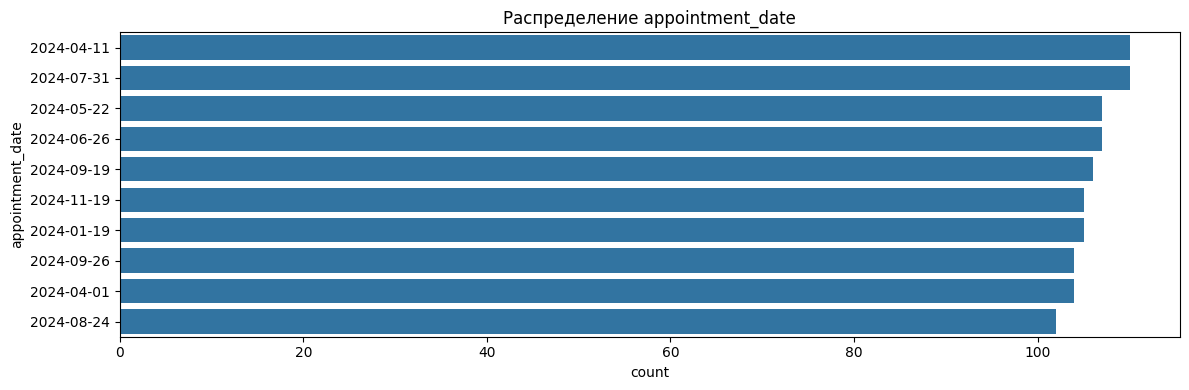

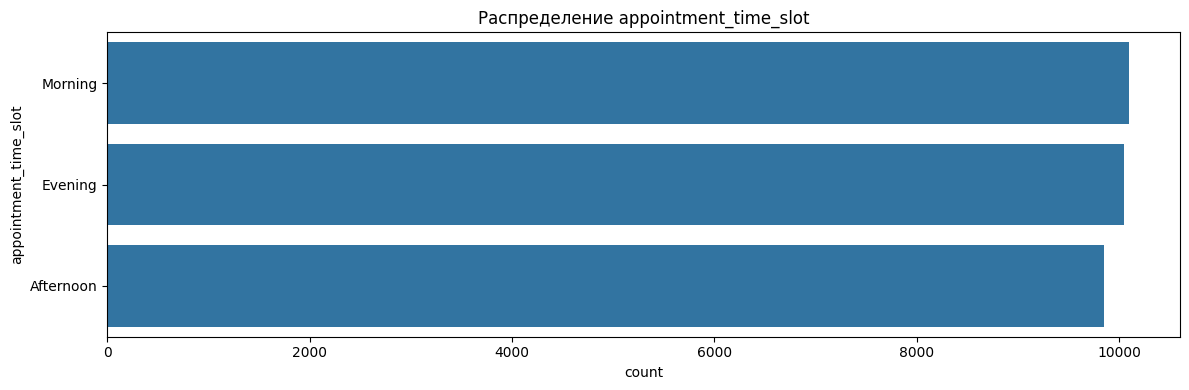

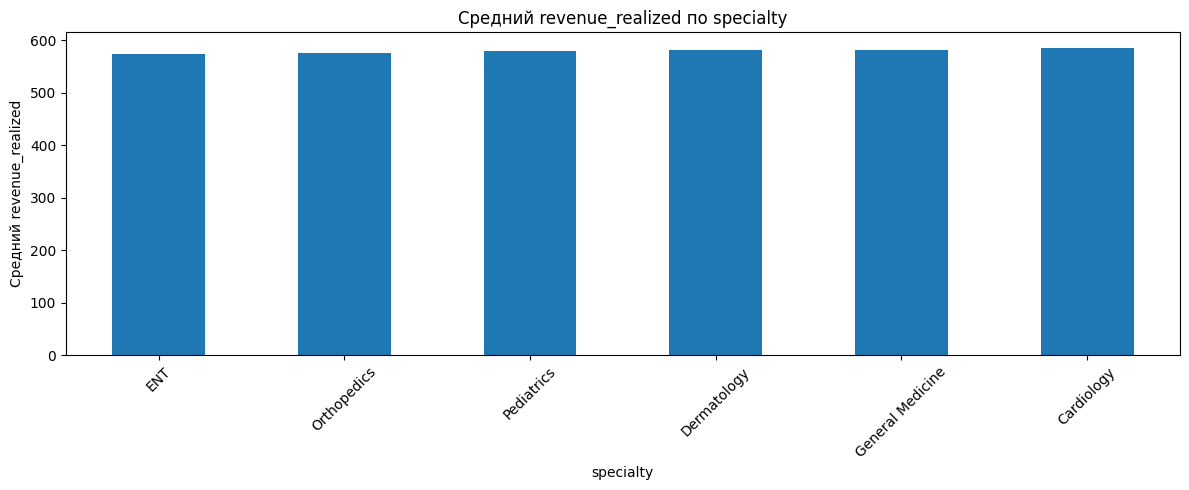

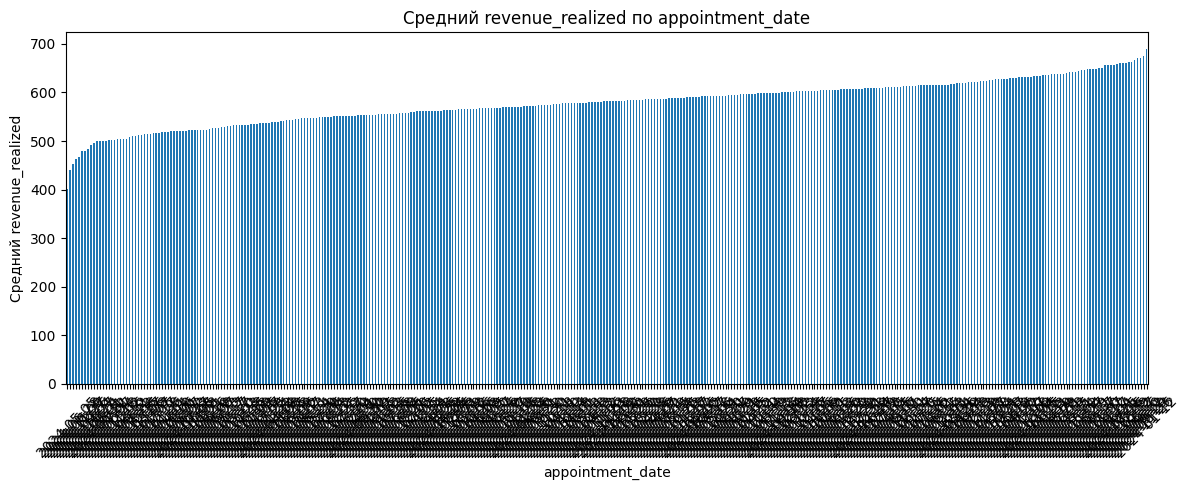

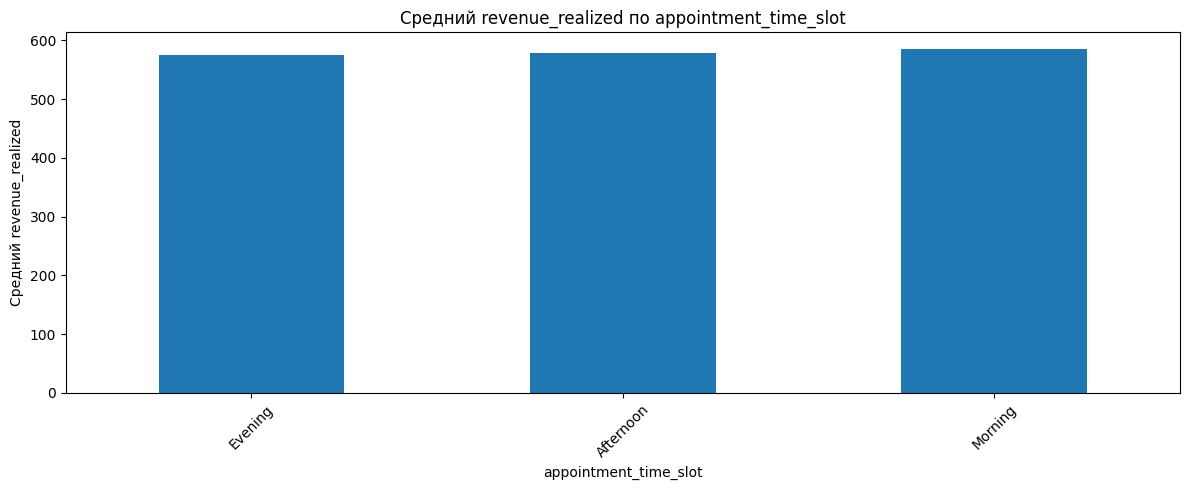

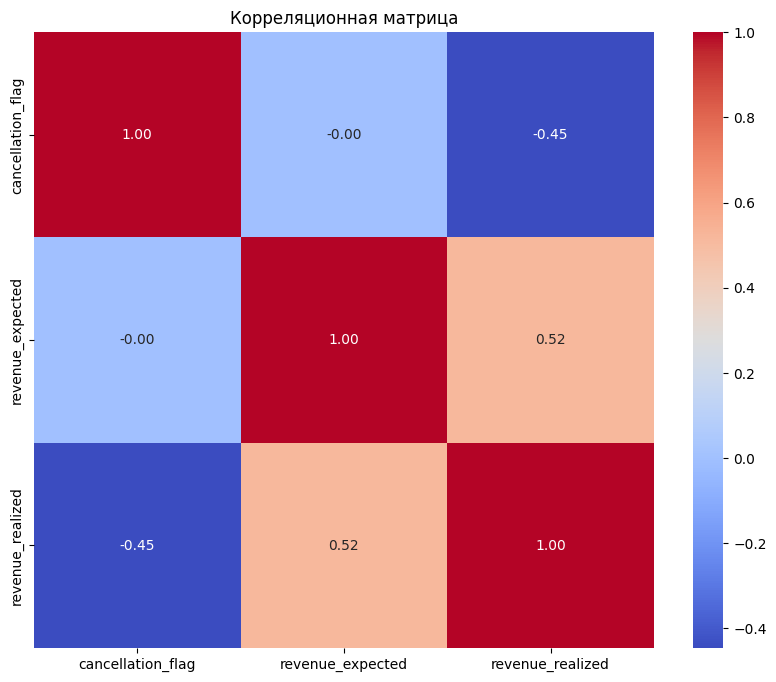

Финальный размер данных: (30000, 376)
   appointment_id  no_show_flag  cancellation_flag  revenue_expected  \
0               1             0                0.0          0.728355   
1               2             1                0.0          1.429183   
2               3             0                0.0         -0.010980   
3               4             0                0.0         -0.261276   
4               5             0                0.0         -0.030234   

   revenue_realized  specialty_Dermatology  specialty_ENT  \
0          0.926910                      1              0   
1         -1.485393                      0              1   
2          0.434708                      0              0   
3          0.268077                      0              1   
4         -1.485393                      0              0   

   specialty_General Medicine  specialty_Orthopedics  specialty_Pediatrics  \
0                           0                      0                     0   
1     

In [5]:
import pandas as pd
import numpy as np
import os
import shutil
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from google.colab import files

# Определяем пути источника и назначения
source_path = 'kaggle.json'
destination_dir = os.path.expanduser('~/.kaggle')
destination_path = os.path.join(destination_dir, 'kaggle.json')

# Создаем директорию назначения, если она не существует
os.makedirs(destination_dir, exist_ok=True)

# Перемещаем файл
shutil.move(source_path, destination_path)

# Устанавливаем права доступа
os.chmod(destination_path, 0o600)

# Загружаем файл
uploaded = files.upload()
!kaggle datasets download -d nudratabbas/multi-location-healthcare-clinic-revenue-dataset

with zipfile.ZipFile('multi-location-healthcare-clinic-revenue-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('multi-location-healthcare-clinic-revenue-dataset')

    # Показать файлы в директории
print(os.listdir('multi-location-healthcare-clinic-revenue-dataset'))

# Загрузка данных

df = pd.read_csv('multi-location-healthcare-clinic-revenue-dataset/patients.csv')
df = pd.read_csv('multi-location-healthcare-clinic-revenue-dataset/clinics.csv')
df = pd.read_csv('multi-location-healthcare-clinic-revenue-dataset/appointments.csv')

# Просматриваем первые несколько строк датасета
print(df.head())

# Получаем общую информацию о датасете
print(df.info())

# АНАЛИЗ распределений (EDA)
# Числовые признаки
num_cols = ['age', 'total_lifetime_visits', 'total_lifetime_revenue', 'cancellation_flag',
            'revenue_expected', 'revenue_realized']
num_cols = [col for col in num_cols if col in df.columns]

# Гистограммы
df[num_cols].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

# Ящики с усами (выбросы)
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# Категориальные признаки
cat_cols = ['gender', 'specialty', 'appointment_date', 'appointment_time_slot',
            'insurance_type']
cat_cols = [col for col in cat_cols if col in df.columns]

for col in cat_cols:
    plt.figure(figsize=(12,4))
    order = df[col].value_counts().iloc[:10].index  # топ-10
    sns.countplot(y=col, data=df, order=order)
    plt.title(f'Распределение {col}')
    plt.tight_layout()
    plt.show()

# Взаимосвязь целевой переменной
target = 'revenue_realized'
if target in df.columns:
    for col in cat_cols:
        plt.figure(figsize=(12,5))
        df.groupby(col)[target].mean().sort_values().plot(kind='bar')
        plt.title(f'Средний {target} по {col}')
        plt.ylabel(f'Средний {target}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


# Корреляция числовых признаков
if len(num_cols) > 1:
    plt.figure(figsize=(10,8))
    sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Корреляционная матрица')
    plt.show()

# Обработка выбросов
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower_bound, upper_bound)

for col in num_cols:
    cap_outliers(df, col)

# Кодирование категориальных признаков
# Выбираем признаки для кодирования
cols_to_encode = ['gender', 'specialty', 'appointment_time_slot', 'appointment_date',
                  'insurance_type']
cols_to_encode = [col for col in cols_to_encode if col in df.columns]

# One-hot encoding (drop_first уменьшает мультиколлинеарность)
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True, dtype=int)

# Масштабирование числовых признаков

# Числовые признаки, которые мы оставляем (не включая закодированные)
num_features = ['age', 'chronic_condition_flag', 'total_lifetime_visits', 'total_lifetime_revenue',
                'cancellation_flag', 'revenue_expected', 'revenue_realized']
num_features = [f for f in num_features if f in df.columns]

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[num_features] = scaler.fit_transform(df[num_features])

# Удаление неинформативных колонок
df_scaled.drop(['patient_id', 'last_visit_days__ago', 'doctor_id', 'clinic_id', 'booking_lead_time_days'], axis=1, inplace=True, errors='ignore')

# Итоговый набор данных
print("Финальный размер данных:", df_scaled.shape)
print(df_scaled.head())

# Сохранение обработанных данных (опционально)
df_scaled.to_csv('patients_processed.csv', index=False)







Размер данных: (30000, 376)

Первые строки:
   appointment_id  no_show_flag  cancellation_flag  revenue_expected  \
0               1             0                0.0          0.728355   
1               2             1                0.0          1.429183   
2               3             0                0.0         -0.010980   
3               4             0                0.0         -0.261276   
4               5             0                0.0         -0.030234   

   revenue_realized  specialty_Dermatology  specialty_ENT  \
0          0.926910                      1              0   
1         -1.485393                      0              1   
2          0.434708                      0              0   
3          0.268077                      0              1   
4         -1.485393                      0              0   

   specialty_General Medicine  specialty_Orthopedics  specialty_Pediatrics  \
0                           0                      0                     0   


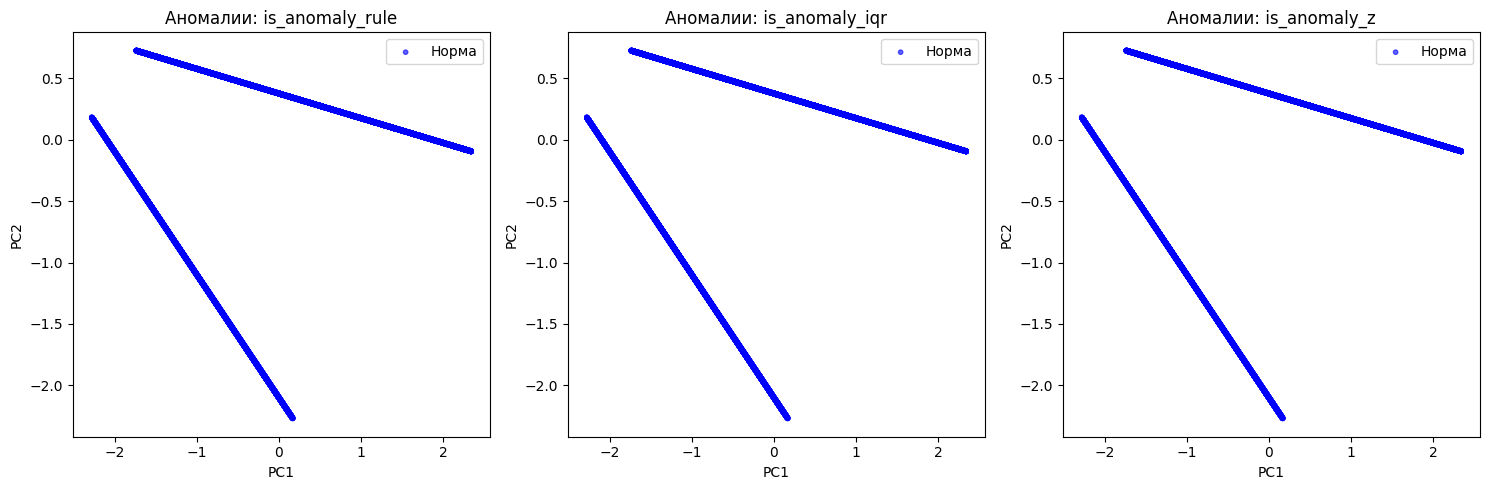


Топ-10 самых аномальных записей:
      revenue_expected  revenue_realized  anomaly_score
554          -1.736095         -1.485393              2
600           1.587061         -1.485393              2
685          -1.582066         -1.485393              2
753           1.710284         -1.485393              2
902          -1.582066         -1.485393              2
1040         -1.543559         -1.485393              2
1094          1.571659         -1.485393              2
1269          1.571659         -1.485393              2
1300          1.717985         -1.485393              2
1328          1.513898         -1.485393              2

Сравнение средних значений:
                     Норма  Аномалия  Разница (%)
revenue_expected -0.000332  0.039079 -11857.70751
revenue_realized  0.012633 -1.485393 -11857.70751


In [13]:
#Поиск аномалий
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем обработанные данные (из предыдущего шага)
df = pd.read_csv('patients_processed.csv')

print("Размер данных:", df.shape)
print("\nПервые строки:")
print(df.head())

df_anomaly = df.copy()
df_anomaly['is_anomaly_rule'] = 0   # 0- норма, 1 - аномалия

# Статистический метод IQR (межквартильный размах)
def detect_iqr_outliers(df, column, factor=1.5):
    """Обнаружение выбросов методом IQR"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR
    outliers = (df[column] < lower_bound) | (df[column] > upper_bound)
    return outliers

# Числовые признаки для анализа
num_cols = ['age', 'total_lifetime_visits', 'total_lifetime_revenue',
            'revenue_expected', 'revenue_realized']
num_cols = [col for col in num_cols if col in df.columns]

# Добавляем флаги для каждого признака
for col in num_cols:
    df_anomaly[f'outlier_iqr_{col}'] = detect_iqr_outliers(df, col)

# Общий флаг аномалии по IQR (хотя бы один признак)
df_anomaly['is_anomaly_iqr'] = df_anomaly[[f'outlier_iqr_{col}' for col in num_cols]].any(axis=1).astype(int)

print("\nАномалии по IQR (хотя бы один признак):", df_anomaly['is_anomaly_iqr'].sum())

# Метод Z-score (стандартизированные оценки)

from scipy import stats

def detect_zscore_outliers(df, column, threshold=3):
    """Обнаружение выбросов по Z-score"""
    z_scores = np.abs(stats.zscore(df[column].dropna()))
    outliers = pd.Series(False, index=df.index)
    outliers[df[column].dropna().index] = z_scores > threshold
    return outliers

for col in num_cols:
    df_anomaly[f'outlier_z_{col}'] = detect_zscore_outliers(df, col, threshold=3)

df_anomaly['is_anomaly_z'] = df_anomaly[[f'outlier_z_{col}' for col in num_cols]].any(axis=1).astype(int)
print("\nАномалии по Z-score (|z|>3):", df_anomaly['is_anomaly_z'].sum())

# Метод Isolation Forest (машинное обучение для аномалий )
from sklearn.ensemble import IsolationForest

# Подготовка данных (только числовые признаки, без пропусков)
X = df[num_cols].fillna(0)

# Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)  # ожидаем ~5% аномалий
df_anomaly['outlier_if'] = iso_forest.fit_predict(X)
# Isolation Forest даёт -1 для аномалий, 1 для нормы
df_anomaly['is_anomaly_if'] = (df_anomaly['outlier_if'] == -1).astype(int)

print("Аномалии по Isolation Forest:", df_anomaly['is_anomaly_if'].sum())

# Метод Local Outlier Factor (LOF)
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=50, contamination=0.05)
df_anomaly['outlier_lof'] = lof.fit_predict(X)
df_anomaly['is_anomaly_lof'] = (df_anomaly['outlier_lof'] == -1).astype(int)

print("Аномалии по LOF:", df_anomaly['is_anomaly_lof'].sum())

# Сводный анализ аномалий
# Собираем все методы в одну таблицу
anomaly_methods = ['is_anomaly_rule', 'is_anomaly_iqr', 'is_anomaly_z',
                   'is_anomaly_if', 'is_anomaly_lof']
anomaly_methods = [m for m in anomaly_methods if m in df_anomaly.columns]

# Сколько аномалий нашёл каждый метод
anomaly_counts = df_anomaly[anomaly_methods].sum()
print("\nКоличество аномалий по методам:")
print(anomaly_counts)

# Пересечения методов
for i, m1 in enumerate(anomaly_methods):
    for m2 in anomaly_methods[i+1:]:
        intersection = ((df_anomaly[m1] == 1) & (df_anomaly[m2] == 1)).sum()
        print(f"Пересечение {m1} и {m2}: {intersection}")

# Общий консенсус (аномалия, если её нашли хотя бы 2 метода)
df_anomaly['is_anomaly_consensus'] = (df_anomaly[anomaly_methods].sum(axis=1) >= 2).astype(int)
print("\nАномалии по консенсусу (>=2 методов):", df_anomaly['is_anomaly_consensus'].sum())


# Визуализация аномалий
# PCA для визуализации
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Масштабируем данные
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.fillna(0))

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(15,5))

# По методам
for i, method in enumerate(anomaly_methods[:3]):  # первые 3 метода
    plt.subplot(1,3,i+1)
    colors = ['blue' if x==0 else 'red' for x in df_anomaly[method]]
    plt.scatter(X_pca[:,0], X_pca[:,1], c=colors, alpha=0.6, s=10)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(f'Аномалии: {method}')
    plt.legend(['Норма', 'Аномалия'])

plt.tight_layout()
plt.show()

# Анализ аномальных записей
# Посмотрим на топ-10 самых аномальных записей (по сумме методов)
df_anomaly['anomaly_score'] = df_anomaly[anomaly_methods].sum(axis=1)
top_anomalies = df_anomaly.nlargest(10, 'anomaly_score')

print("\nТоп-10 самых аномальных записей:")
print(top_anomalies[num_cols + ['anomaly_score']])

# Сравнение статистик нормальных и аномальных записей
normal = df_anomaly[df_anomaly['is_anomaly_consensus'] == 0]
anomaly = df_anomaly[df_anomaly['is_anomaly_consensus'] == 1]

print("\nСравнение средних значений:")
comparison = pd.DataFrame({
    'Норма': normal[num_cols].mean(),
    'Аномалия': anomaly[num_cols].mean(),
    'Разница (%)': ((anomaly[num_cols].mean() - normal[num_cols].mean()) / normal[num_cols].mean() * 100)
})
print(comparison)





In [1]:
!pip install --upgrade scikit-learn

Доступные колонки
['appointment_id', 'no_show_flag', 'cancellation_flag', 'revenue_expected', 'revenue_realized', 'specialty_Dermatology', 'specialty_ENT', 'specialty_General Medicine', 'specialty_Orthopedics', 'specialty_Pediatrics', 'appointment_time_slot_Evening', 'appointment_time_slot_Morning', 'appointment_date_2024-01-02', 'appointment_date_2024-01-03', 'appointment_date_2024-01-04', 'appointment_date_2024-01-05', 'appointment_date_2024-01-06', 'appointment_date_2024-01-07', 'appointment_date_2024-01-08', 'appointment_date_2024-01-09', 'appointment_date_2024-01-10', 'appointment_date_2024-01-11', 'appointment_date_2024-01-12', 'appointment_date_2024-01-13', 'appointment_date_2024-01-14', 'appointment_date_2024-01-15', 'appointment_date_2024-01-16', 'appointment_date_2024-01-17', 'appointment_date_2024-01-18', 'appointment_date_2024-01-19', 'appointment_date_2024-01-20', 'appointment_date_2024-01-21', 'appointment_date_2024-01-22', 'appointment_date_2024-01-23', 'appointment_date

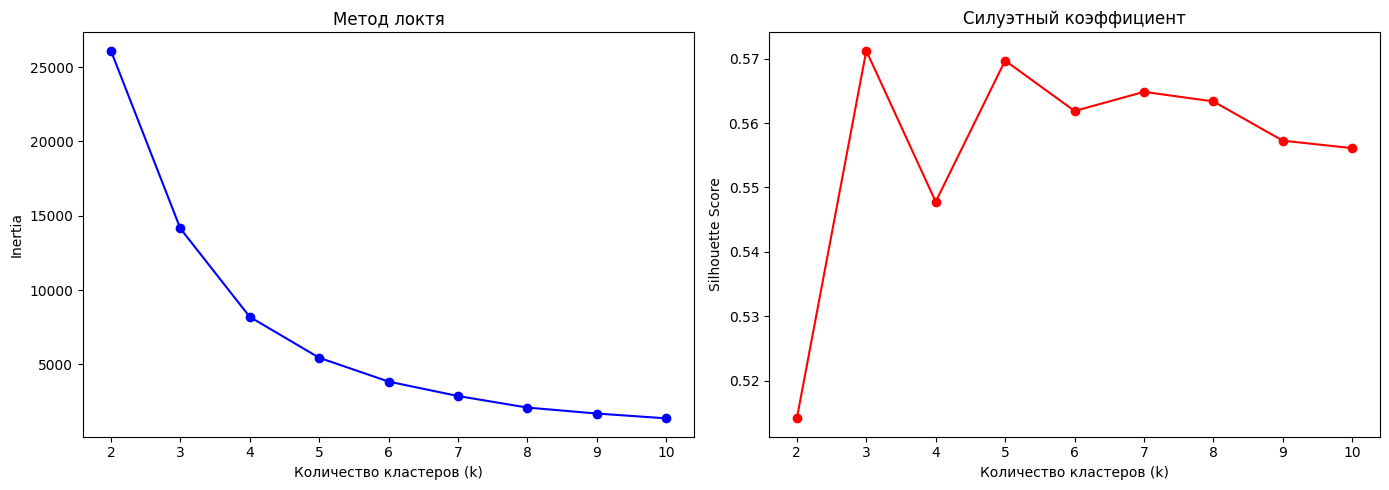

Профили кластеров K-Means:
                revenue_expected  revenue_realized
kmeans_cluster                                    
0                       0.795428          0.971562
1                      -0.976077         -0.415005
2                       0.569216         -1.485393


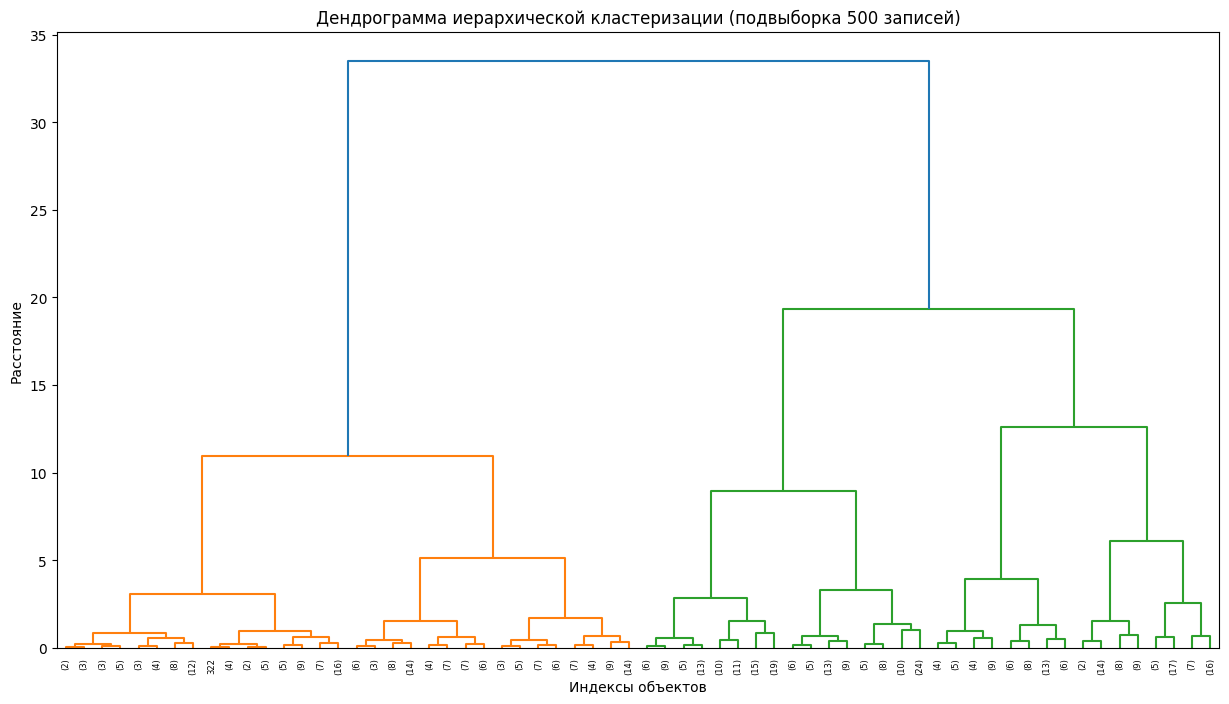

Распределение по кластерам (иерархическая):
hierarchical_cluster
2    10399
1     9559
0     5226
3     4816
Name: count, dtype: int64


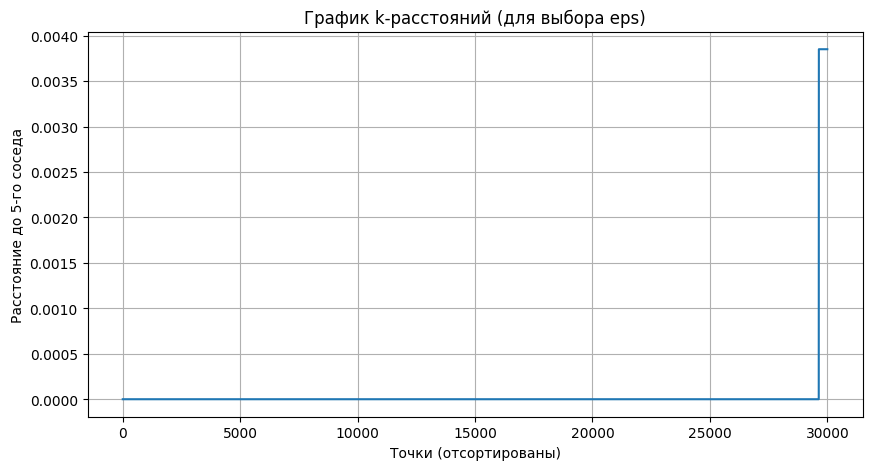

DBSCAN: найдено кластеров: 2
Шумовых точек (выбросов): 0 (0.00%)

Профили кластеров DBSCAN (без шума):
                revenue_expected  revenue_realized
dbscan_cluster                                    
0                       0.001382          0.442938
1                      -0.004635         -1.485393


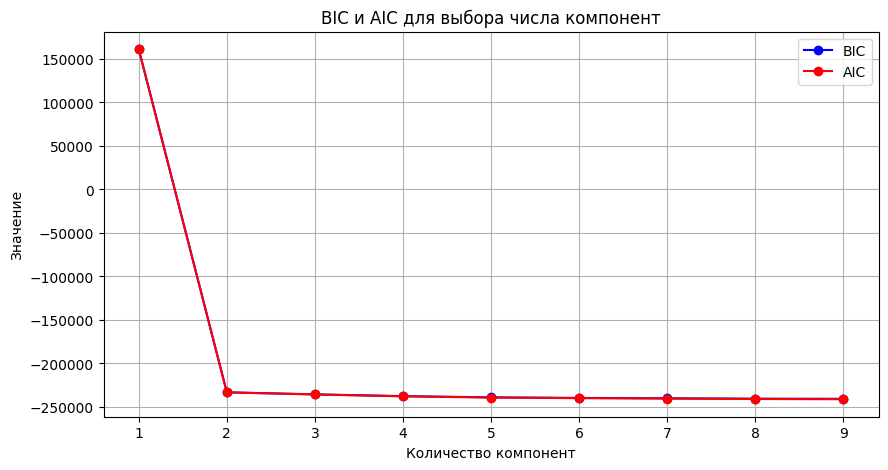


Профили кластеров GMM:
             revenue_expected  revenue_realized
gmm_cluster                                    
0                   -1.475165         -0.540054
1                    0.263069          0.617152
2                   -0.004635         -1.485393

Уверенность кластеризации (средняя вероятность):
gmm_cluster
0    0.718684
1    0.979639
2    1.000000
Name: gmm_max_prob, dtype: float64
OPTICS: найдено кластеров: 2
Шумовых точек: 0

=== Сравнение методов кластеризации ===
       Метод  Силуэт (↑)  Калински-Харабас (↑)  Дэвис-Болдин (↓)  Кол-во кластеров
     K-Means    0.571234          48641.389192          0.613978                 3
Hierarchical    0.520931          53010.877269          0.615176                 4
      DBSCAN    0.420662          14706.503346          0.986889                 2
         GMM    0.358186          17874.782458          0.744805                 3
      OPTICS    0.420662          14706.503346          0.986889                 2


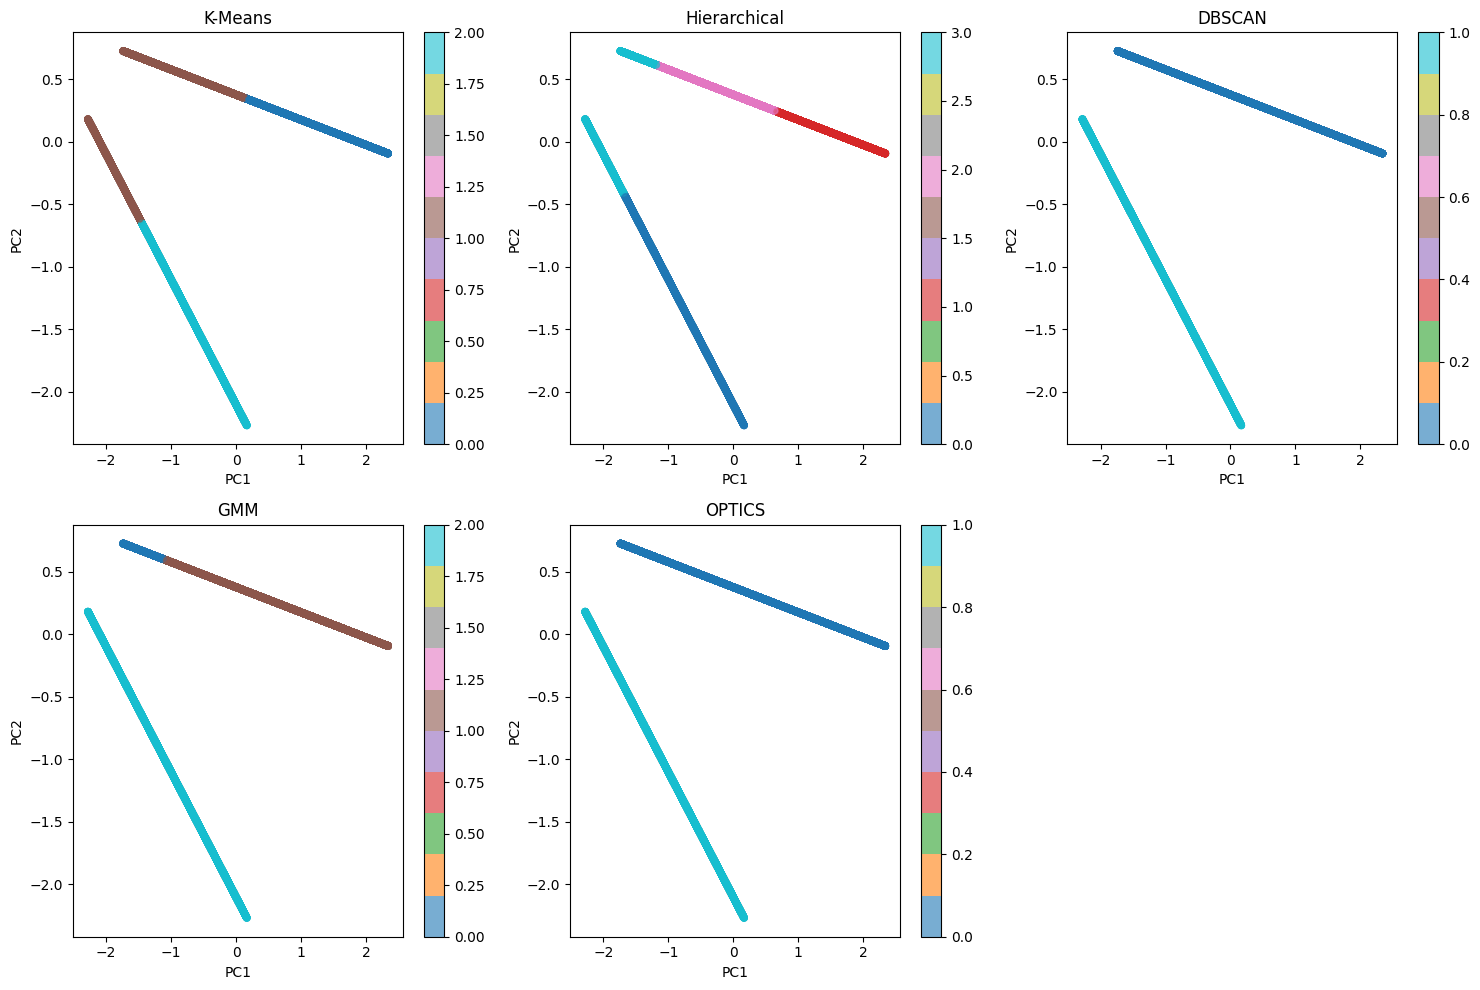


ИТОГОВЫЙ АНАЛИЗ МЕТОДОВ КЛАСТЕРИЗАЦИИ

 Лучшие модели по каждой метрике:
   • Силуэт (↑)          : K-Means = 0.5712
   • Калински-Харабас (↑): Hierarchical = 53010.88
   • Дэвис-Болдин (↓)    : K-Means = 0.6140

 Худшие модели по каждой метрике:
   • Силуэт (↑)          : GMM = 0.3582
   • Калински-Харабас (↑): DBSCAN = 14706.50
   • Дэвис-Болдин (↓)    : DBSCAN = 0.9869


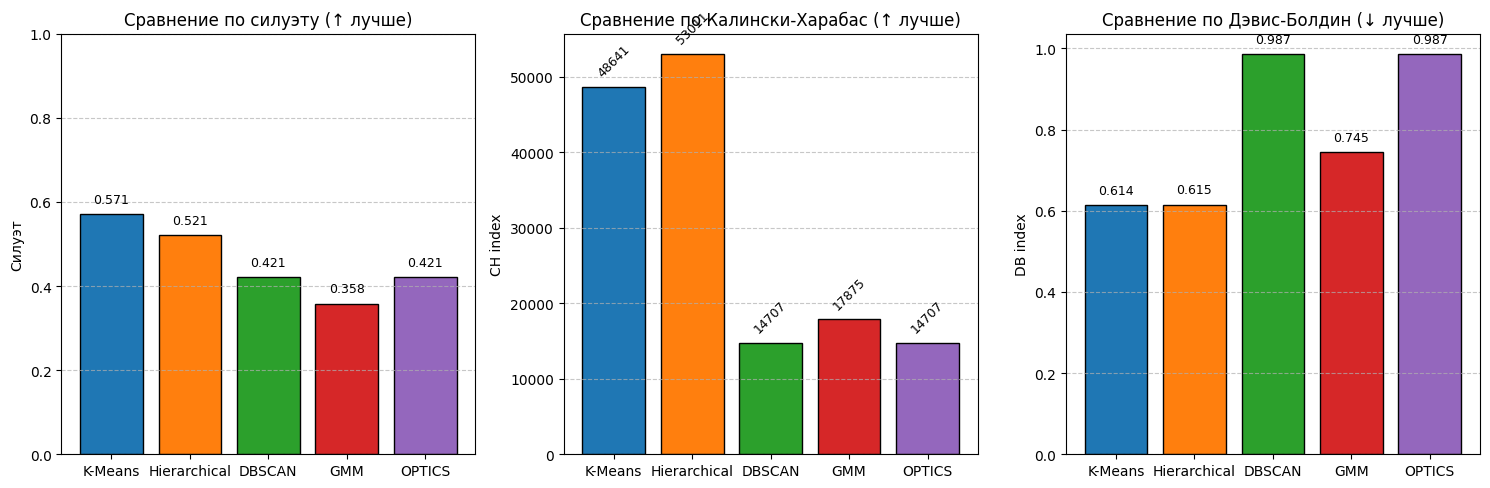


 Интегральная оценка (среднее нормализованных метрик, чем выше тем лучше):
   K-Means     : 0.9620
   Hierarchical: 0.9202
   DBSCAN      : 0.0977
   GMM         : 0.2440
   OPTICS      : 0.0977

 Лучшая модель по интегральной оценке: K-Means = 0.9620
 Худшая модель по интегральной оценке : DBSCAN = 0.0977


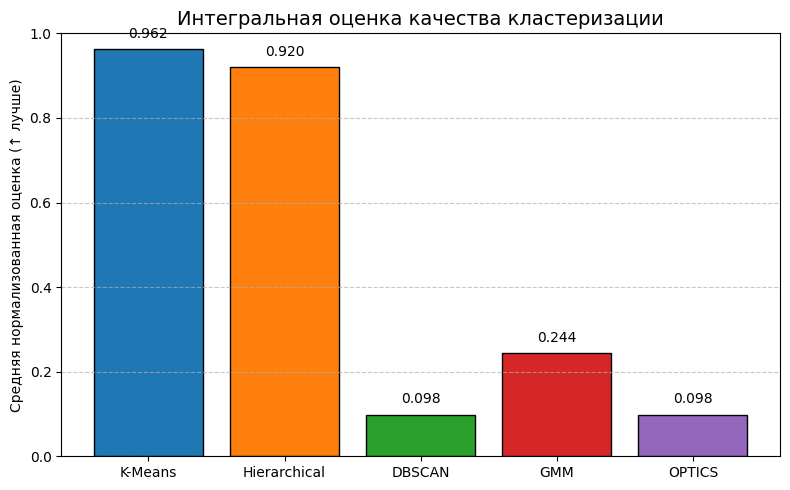

In [3]:
# Кластеризация
# 1. К-Means
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.mixture import GaussianMixture
from sklearn.cluster import OPTICS

# Загружаем обработанные данные
df = pd.read_csv('patients_processed.csv')

# Показать все колонки датасета
print("Доступные колонки")
print(df.columns.tolist())

# Выбираем признаки для кластеризации
features = ['revenue_expected', 'revenue_realized']
X = df[features].copy()

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA для визуализации и уменьшения размерности
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Выбрано компонент: {pca.n_components_}")
print(f"Объясненная дисперсия: {pca.explained_variance_ratio_.sum():.2%}")

# Поиск оптимального K (метод локтя)
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertia, 'bo-')
ax1.set_xlabel('Количество кластеров (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Метод локтя')

ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Количество кластеров (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Силуэтный коэффициент')

plt.tight_layout()
plt.show()

# Выбираем оптимальное k (например, 3)
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_pca)

# Профили кластеров
print("Профили кластеров K-Means:")
print(df.groupby('kmeans_cluster')[features].mean())

# 2. Иерархическая кластеризация (Agglomerative)
# Дендрограмма на подвыборке (только для визуализации)
sample_size = min(500, len(df))
X_sample = X_pca[:sample_size]
Z_sample = linkage(X_sample, method='ward')

plt.figure(figsize=(15, 8))
dendrogram(Z_sample, truncate_mode='level', p=5)
plt.title('Дендрограмма иерархической кластеризации (подвыборка 500 записей)')
plt.xlabel('Индексы объектов')
plt.ylabel('Расстояние')
plt.show()

# Выбираем число кластеров (например, 4)
n_clusters = 4
agg_clustering = AgglomerativeClustering(n_clusters=n_clusters)
df['hierarchical_cluster'] = agg_clustering.fit_predict(X_pca)

print("Распределение по кластерам (иерархическая):")
print(df['hierarchical_cluster'].value_counts())

# 3. DBSCAN
# Определяем оптимальный eps (метод k-расстояний)
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)
distances = np.sort(distances[:, 4], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.xlabel('Точки (отсортированы)')
plt.ylabel('Расстояние до 5-го соседа')
plt.title('График k-расстояний (для выбора eps)')
plt.grid(True)
plt.show()

# Выбираем eps по изгибу графика (например, 0.5)
eps_value = 0.5
dbscan = DBSCAN(eps=eps_value, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_pca)

# Статистика
n_clusters_dbscan = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
n_noise = list(df['dbscan_cluster']).count(-1)

print(f"DBSCAN: найдено кластеров: {n_clusters_dbscan}")
print(f"Шумовых точек (выбросов): {n_noise} ({n_noise/len(df)*100:.2f}%)")

print("\nПрофили кластеров DBSCAN (без шума):")
print(df[df['dbscan_cluster'] != -1].groupby('dbscan_cluster')[features].mean())

# 4. Gaussian Mixture Models (GMM)
# Поиск оптимального числа компонент (по BIC/AIC)
bic_scores = []
aic_scores = []
n_components_range = range(1, 10)

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_pca)
    bic_scores.append(gmm.bic(X_pca))
    aic_scores.append(gmm.aic(X_pca))

plt.figure(figsize=(10, 5))
plt.plot(n_components_range, bic_scores, 'bo-', label='BIC')
plt.plot(n_components_range, aic_scores, 'ro-', label='AIC')
plt.xlabel('Количество компонент')
plt.ylabel('Значение')
plt.title('BIC и AIC для выбора числа компонент')
plt.legend()
plt.grid(True)
plt.show()

# Выбираем оптимальное число (например, 3)
n_optimal = 3
gmm = GaussianMixture(n_components=n_optimal, random_state=42)
gmm.fit(X_pca)

# Мягкая кластеризация (вероятности)
probs = gmm.predict_proba(X_pca)
df['gmm_cluster'] = gmm.predict(X_pca)
df['gmm_max_prob'] = probs.max(axis=1)

print("\nПрофили кластеров GMM:")
print(df.groupby('gmm_cluster')[features].mean())
print("\nУверенность кластеризации (средняя вероятность):")
print(df.groupby('gmm_cluster')['gmm_max_prob'].mean())

# 5. OPTICS
import warnings

with warnings.catch_warnings():
  warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn.cluster._optics")


optics = OPTICS(min_samples=50, xi=0.1, min_cluster_size=0.05)
df['optics_cluster'] = optics.fit_predict(X_pca)

n_clusters_optics = len(set(df['optics_cluster'])) - (1 if -1 in df['optics_cluster'].values else 0)
n_noise_optics = list(df['optics_cluster']).count(-1)
print(f"OPTICS: найдено кластеров: {n_clusters_optics}")
print(f"Шумовых точек: {n_noise_optics}")

# СРАВНЕНИЕ ВСЕХ МЕТОДОВ
# --- Сбор метрик качества ---
cluster_columns = {
    'K-Means': 'kmeans_cluster',
    'Hierarchical': 'hierarchical_cluster',
    'DBSCAN': 'dbscan_cluster',
    'GMM': 'gmm_cluster',
    'OPTICS': 'optics_cluster'
}

metrics = []
for method_name, col in cluster_columns.items():
    labels = df[col].values
    # Для DBSCAN и OPTICS исключаем шум (метка -1)
    if method_name in ['DBSCAN', 'OPTICS']:
        mask = labels != -1
        if mask.sum() == 0:
            print(f"В {method_name} все точки – шум, пропускаем")
            continue
        X_clean = X_scaled[mask]
        labels_clean = labels[mask]
    else:
        X_clean = X_scaled
        labels_clean = labels

    if len(set(labels_clean)) < 2:
        print(f"В {method_name} меньше 2 кластеров, пропускаем")
        continue

    sil = silhouette_score(X_clean, labels_clean)
    ch = calinski_harabasz_score(X_clean, labels_clean)
    db = davies_bouldin_score(X_clean, labels_clean)

    metrics.append({
        'Метод': method_name,
        'Силуэт (↑)': sil,
        'Калински-Харабас (↑)': ch,
        'Дэвис-Болдин (↓)': db,
        'Кол-во кластеров': len(set(labels_clean))
    })

# Вывод таблицы с метриками
metrics_df = pd.DataFrame(metrics)
print("\n=== Сравнение методов кластеризации ===")
print(metrics_df.to_string(index=False))

# перед визуализацией убедимся, что колонки pca1 и pca2 существуют
if 'pca1' not in df.columns:
  from sklearn.decomposition import PCA
  pca = PCA(n_components=2)
  X_pca = pca.fit_transform(X_scaled)
  df['pca1'] = X_pca[:, 0]
  df['pca2'] = X_pca[:, 1]

# --- Визуализация кластеров в PCA-пространстве ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, (method_name, col) in zip(axes, cluster_columns.items()):
    scatter = ax.scatter(df['pca1'], df['pca2'], c=df[col], cmap='tab10', alpha=0.6, s=20)
    ax.set_title(method_name)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    plt.colorbar(scatter, ax=ax)

# Удаляем лишний подграфик (если методов меньше 6)
for i in range(len(cluster_columns), len(axes)):
    axes[i].remove()

plt.tight_layout()
plt.show()

# Анализ и выбор лучшей модели кластеризации
# На основе полученных метрик (metrics_df) определим лучший и худший метод
# по каждому критерию и визуализируем сравнение.

print("\n" + "="*50)
print("ИТОГОВЫЙ АНАЛИЗ МЕТОДОВ КЛАСТЕРИЗАЦИИ")
print("="*50)

# 1. Определение лучшей и худшей модели по каждой метрике
# (Силуэт – чем выше, тем лучше; Калински-Харабас – чем выше, тем лучше;
#  Дэвис-Болдин – чем ниже, тем лучше)

best_sil = metrics_df.loc[metrics_df['Силуэт (↑)'].idxmax()]
worst_sil = metrics_df.loc[metrics_df['Силуэт (↑)'].idxmin()]

best_ch = metrics_df.loc[metrics_df['Калински-Харабас (↑)'].idxmax()]
worst_ch = metrics_df.loc[metrics_df['Калински-Харабас (↑)'].idxmin()]

best_db = metrics_df.loc[metrics_df['Дэвис-Болдин (↓)'].idxmin()]
worst_db = metrics_df.loc[metrics_df['Дэвис-Болдин (↓)'].idxmax()]

print("\n Лучшие модели по каждой метрике:")
print(f"   • Силуэт (↑)          : {best_sil['Метод']} = {best_sil['Силуэт (↑)']:.4f}")
print(f"   • Калински-Харабас (↑): {best_ch['Метод']} = {best_ch['Калински-Харабас (↑)']:.2f}")
print(f"   • Дэвис-Болдин (↓)    : {best_db['Метод']} = {best_db['Дэвис-Болдин (↓)']:.4f}")

print("\n Худшие модели по каждой метрике:")
print(f"   • Силуэт (↑)          : {worst_sil['Метод']} = {worst_sil['Силуэт (↑)']:.4f}")
print(f"   • Калински-Харабас (↑): {worst_ch['Метод']} = {worst_ch['Калински-Харабас (↑)']:.2f}")
print(f"   • Дэвис-Болдин (↓)    : {worst_db['Метод']} = {worst_db['Дэвис-Болдин (↓)']:.4f}")

# 2. Визуализация сравнения метрик
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Цвета для методов (для согласованности на всех графиках)
methods = metrics_df['Метод'].tolist()
colors = plt.cm.tab10(range(len(methods)))

# Силуэт
ax = axes[0]
bars = ax.bar(methods, metrics_df['Силуэт (↑)'], color=colors, edgecolor='black')
ax.set_title('Сравнение по силуэту (↑ лучше)', fontsize=12)
ax.set_ylabel('Силуэт')
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.7)
# Добавим значения на столбцы
for bar, val in zip(bars, metrics_df['Силуэт (↑)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Калински-Харабас
ax = axes[1]
bars = ax.bar(methods, metrics_df['Калински-Харабас (↑)'], color=colors, edgecolor='black')
ax.set_title('Сравнение по Калински-Харабас (↑ лучше)', fontsize=12)
ax.set_ylabel('CH index')
ax.grid(axis='y', linestyle='--', alpha=0.7)
for bar, val in zip(bars, metrics_df['Калински-Харабас (↑)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{val:.0f}', ha='center', va='bottom', fontsize=9, rotation=45)

# Дэвис-Болдин
ax = axes[2]
bars = ax.bar(methods, metrics_df['Дэвис-Болдин (↓)'], color=colors, edgecolor='black')
ax.set_title('Сравнение по Дэвис-Болдин (↓ лучше)', fontsize=12)
ax.set_ylabel('DB index')
ax.grid(axis='y', linestyle='--', alpha=0.7)
for bar, val in zip(bars, metrics_df['Дэвис-Болдин (↓)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 3. Дополнительный анализ: нормализованная средняя оценка
# Нормализуем каждую метрику так, чтобы большее значение соответствовало лучшему качеству.
# Для DB инвертируем (1 - норм_значение, где норм_значение = (max - val)/(max - min)).
# Затем усредним по трём метрикам.

# Нормализация Min-Max для каждой метрики отдельно
def normalize(series, higher_is_better=True):
    minv, maxv = series.min(), series.max()
    if minv == maxv:
        return 0.5
    if higher_is_better:
        return (series - minv) / (maxv - minv)
    else:
        return (maxv - series) / (maxv - minv)

norm_sil = normalize(metrics_df['Силуэт (↑)'], higher_is_better=True)
norm_ch = normalize(metrics_df['Калински-Харабас (↑)'], higher_is_better=True)
norm_db = normalize(metrics_df['Дэвис-Болдин (↓)'], higher_is_better=False)

# Интегральная оценка (среднее арифметическое)
integral_score = (norm_sil + norm_ch + norm_db) / 3
metrics_df['Интегральная оценка'] = integral_score

print("\n Интегральная оценка (среднее нормализованных метрик, чем выше тем лучше):")
for i, row in metrics_df.iterrows():
    print(f"   {row['Метод']:12}: {row['Интегральная оценка']:.4f}")

best_integral = metrics_df.loc[metrics_df['Интегральная оценка'].idxmax()]
worst_integral = metrics_df.loc[metrics_df['Интегральная оценка'].idxmin()]

print(f"\n Лучшая модель по интегральной оценке: {best_integral['Метод']} = {best_integral['Интегральная оценка']:.4f}")
print(f" Худшая модель по интегральной оценке : {worst_integral['Метод']} = {worst_integral['Интегральная оценка']:.4f}")

# Построим график интегральной оценки
plt.figure(figsize=(8,5))
bars = plt.bar(metrics_df['Метод'], metrics_df['Интегральная оценка'], color=colors, edgecolor='black')
plt.title('Интегральная оценка качества кластеризации', fontsize=14)
plt.ylabel('Средняя нормализованная оценка (↑ лучше)')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar, val in zip(bars, metrics_df['Интегральная оценка']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()



